In [31]:
# Exploratory Data Analysis - Dr. Friend Dataset
# Date: May 21, 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
Pandas version: 2.3.3
NumPy version: 2.3.5


In [32]:
# Load the dataset
data_path = '../data/dr_friend_dataset.csv'
df = pd.read_csv(data_path)
df.head()



,row_id,age,gender,height_cm,weight_kg,bmi,temperature_c,heart_rate_bpm,systolic_bp,diastolic_bp,pulse_pressure,spo2_percent,respiratory_rate,blood_glucose_mgdl,symptom_duration_days,sym_cough,sym_productive_cough,sym_shortness_of_breath,sym_wheezing,sym_chest_tightness,sym_chest_pain,sym_nasal_congestion,sym_sore_throat,sym_fever,sym_chills,sym_fatigue,sym_weakness,sym_night_sweats,sym_loss_of_appetite,sym_nausea,sym_vomiting,sym_palpitations,sym_dizziness,sym_fainting,sym_swollen_ankles,sym_cold_extremities,sym_abdominal_pain,sym_diarrhoea,sym_constipation,sym_jaundice,sym_headache,sym_blurred_vision,sym_numbness_tingling,sym_confusion,sym_light_sensitivity,sym_excessive_thirst,sym_frequent_urination,sym_unexplained_weight_loss,sym_excessive_sweating,sym_joint_pain,sym_muscle_aches,sym_back_pain,disease,broad_category,comorbidity
0,0,48,Female,152.90,48.80,20.90,39.90,62,97.00,NaN,24.00,95.70,18.00,94.00,12,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,Typhoid,Infectious,NaN
1,1,42,Male,167.90,62.50,22.20,37.40,94,159.00,84.00,67.00,100.00,15.00,182.00,18,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,1,1,1,1,0,0,0,Type 2 Diabetes,Metabolic,NaN
2,2,34,Female,148.80,67.70,30.60,39.70,118,133.00,55.00,56.00,93.00,23.00,110.00,2,1,0,1,0,1,1,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,Pneumonia,Respiratory,NaN
3,3,37,Female,152.60,57.00,24.50,37.60,107,114.00,60.00,54.00,91.00,16.00,NaN,8,0,0,1,0,1,0,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,COVID-19,Respiratory,NaN
4,4,25,Male,167.50,99.90,35.60,37.60,125,133.00,79.00,54.00,97.00,NaN,107.00,1,0,0,1,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,Anxiety Attack,Neurological,NaN


# Basic Data check

In [33]:
print(f"\nDataset shape: {df.shape}")
print(f"  - Total rows: {df.shape[0]:,}")
print(f"  - Total columns: {df.shape[1]}")



Dataset shape: (3000, 55)
  - Total rows: 3,000
  - Total columns: 55


# Checking for missing values

In [34]:
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)


MISSING VALUES
                    Missing Count  Percentage
comorbidity                  2701       90.03
respiratory_rate              646       21.53
blood_glucose_mgdl            478       15.93
diastolic_bp                  258        8.60
systolic_bp                   240        8.00
pulse_pressure                240        8.00


In [35]:
#class distribution analysis
# Class distribution
print("=" * 80)
print("DISEASE DISTRIBUTION")
print("=" * 80)

disease_counts = df['disease'].value_counts().sort_values(ascending=False)
disease_pct = (disease_counts / len(df)) * 100

dist_df = pd.DataFrame({
    'Count': disease_counts,
    'Percentage': disease_pct
})
print(dist_df)
print(f"\nTotal diseases: {df['disease'].nunique()}")

DISEASE DISTRIBUTION
                     Count  Percentage
disease                               
Bronchitis             291        9.70
Migraine               265        8.83
Asthma                 264        8.80
Anxiety Attack         245        8.17
COVID-19               242        8.07
Type 2 Diabetes        233        7.77
Pneumonia              212        7.07
Typhoid                211        7.03
Dengue Fever           200        6.67
Malaria                189        6.30
Anaemia                182        6.07
Hypothyroidism         155        5.17
Arrhythmia             117        3.90
Hypertensive Crisis     92        3.07
Heart Failure           91        3.03
COPD                    11        0.37

Total diseases: 16


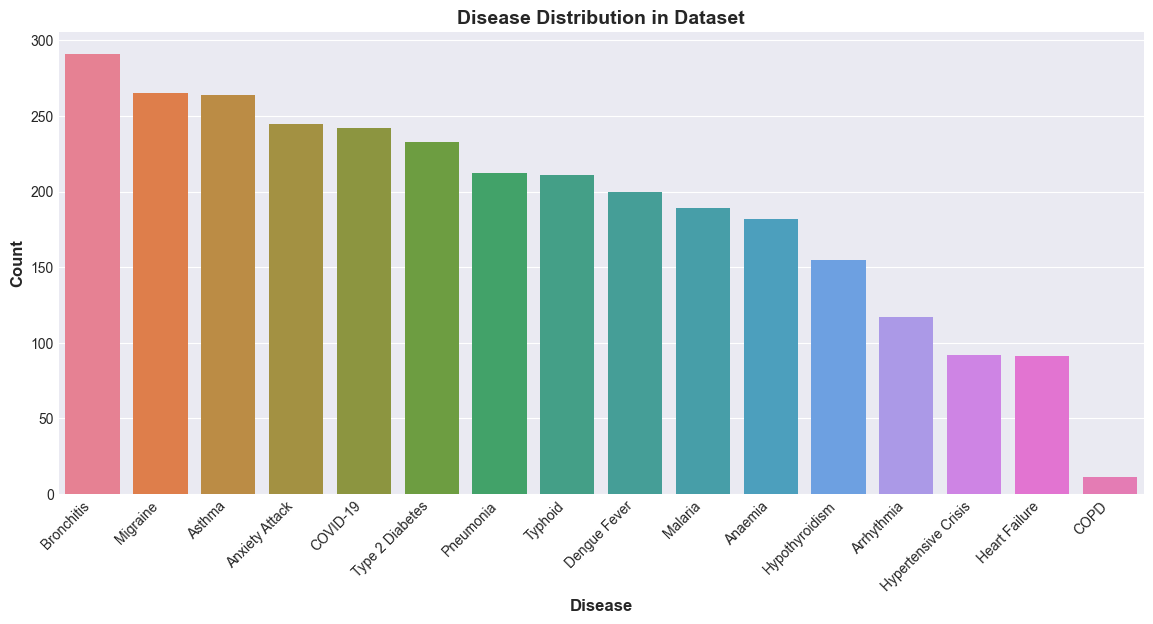

In [36]:
#Visualize
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=disease_counts.index, y=disease_counts.values, hue=disease_counts.index, legend=False)
plt.xlabel('Disease', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Disease Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

VITAL SIGNS - DESCRIPTIVE STATISTICS BY DISEASE

TEMPERATURE C
--------------------------------------------------------------------------------
                     mean  std   min   max
disease                                   
Anaemia             36.78 0.31 35.70 37.50
Anxiety Attack      36.98 0.31 36.30 37.70
Arrhythmia          36.77 0.29 36.20 37.50
Asthma              36.81 0.40 36.00 39.30
Bronchitis          37.78 0.47 36.30 39.40
COPD                37.78 0.85 36.40 39.40
COVID-19            38.53 0.67 36.10 40.50
Dengue Fever        39.56 0.57 38.50 41.00
Heart Failure       36.84 0.41 36.00 37.80
Hypertensive Crisis 37.07 0.29 36.50 37.80
Hypothyroidism      36.33 0.29 35.70 37.20
Malaria             39.68 0.77 38.00 41.50
Migraine            36.78 0.30 36.20 37.50
Pneumonia           38.93 0.66 36.60 40.90
Type 2 Diabetes     36.90 0.32 36.20 37.70
Typhoid             39.22 0.60 38.00 40.90

HEART RATE BPM
------------------------------------------------------------------

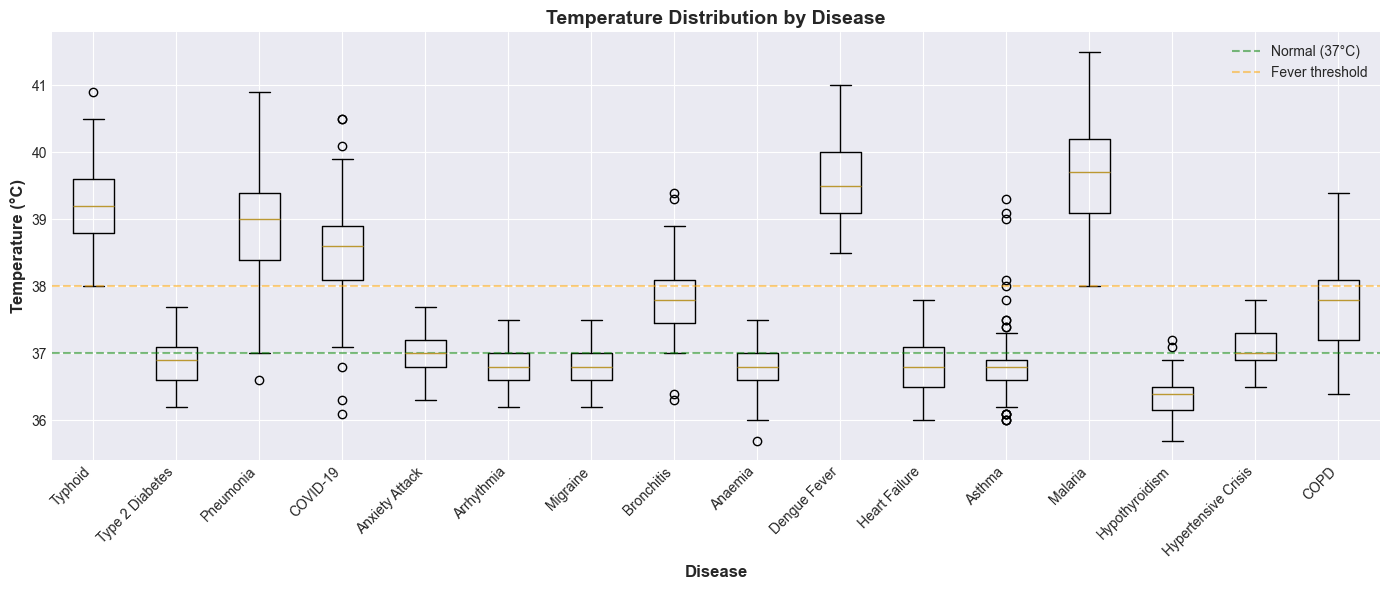

In [37]:
# Vital signs summary statistics by disease
print("=" * 80)
print("VITAL SIGNS - DESCRIPTIVE STATISTICS BY DISEASE")
print("=" * 80)

vital_cols = ['temperature_c', 'heart_rate_bpm', 'systolic_bp', 'diastolic_bp', 
              'spo2_percent', 'respiratory_rate', 'blood_glucose_mgdl']

for vital in vital_cols:
    print(f"\n{vital.upper().replace('_', ' ')}")
    print("-" * 80)
    vital_by_disease = df.groupby('disease')[vital].agg(['mean', 'std', 'min', 'max']).round(2)
    print(vital_by_disease)

# Visualize temperature distribution
print("\n" + "=" * 80)
print("TEMPERATURE DISTRIBUTION BY DISEASE")
print("=" * 80)

plt.figure(figsize=(14, 6))
diseases = df['disease'].unique()
temp_data = [df[df['disease'] == d]['temperature_c'].dropna() for d in diseases]

plt.boxplot(temp_data, labels=diseases)
plt.xlabel('Disease', fontsize=12, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
plt.title('Temperature Distribution by Disease', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=37.0, color='green', linestyle='--', label='Normal (37°C)', alpha=0.5)
plt.axhline(y=38.0, color='orange', linestyle='--', label='Fever threshold', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

SYMPTOM ANALYSIS (38 symptoms)

Symptom columns identified: ['sym_cough', 'sym_productive_cough', 'sym_shortness_of_breath', 'sym_wheezing', 'sym_chest_tightness', 'sym_chest_pain', 'sym_nasal_congestion', 'sym_sore_throat', 'sym_fever', 'sym_chills']... (showing first 10)

Top 15 Most Common Symptoms:
                         Frequency  Percentage
sym_fatigue                   2168       72.27
sym_weakness                  1574       52.47
sym_headache                  1483       49.43
sym_shortness_of_breath       1305       43.50
sym_fever                     1263       42.10
sym_loss_of_appetite          1251       41.70
sym_nausea                    1125       37.50
sym_cough                     1098       36.60
sym_dizziness                 1076       35.87
sym_muscle_aches              1014       33.80
sym_chest_tightness            904       30.13
sym_chills                     830       27.67
sym_palpitations               752       25.07
sym_vomiting                   707    

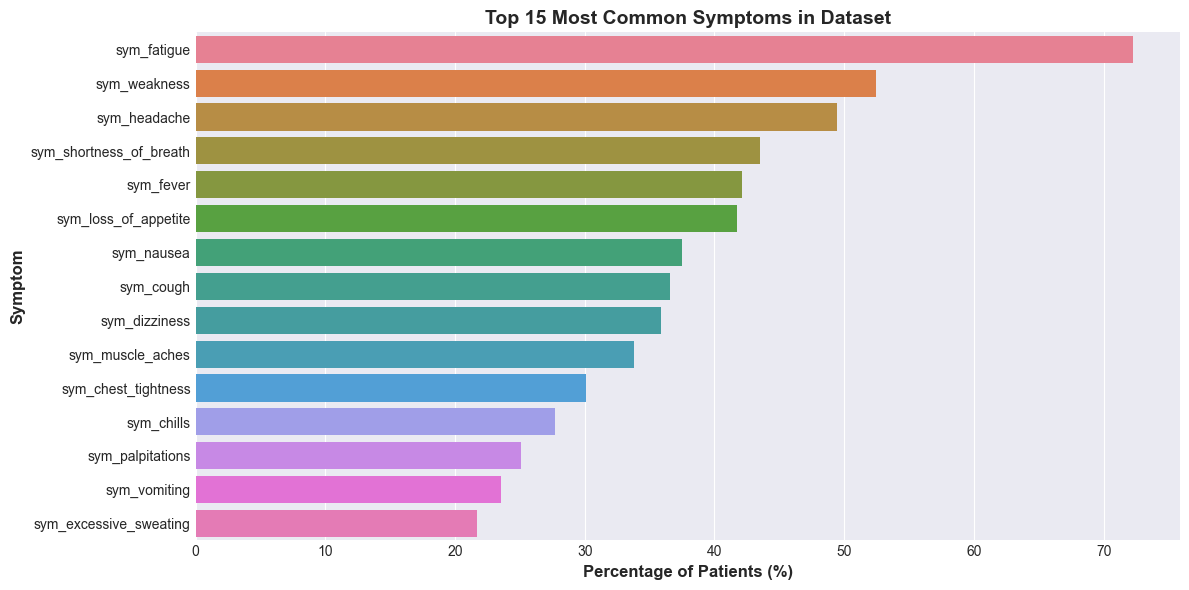


 Average symptoms per patient: 9.14


In [39]:
# Get symptom columns more explicitly
non_symptom_cols = ['age', 'gender', 'height_cm', 'weight_kg', 'bmi', 
                    'temperature_c', 'heart_rate_bpm', 'systolic_bp', 'diastolic_bp',
                    'pulse_pressure', 'spo2_percent', 'respiratory_rate', 
                    'blood_glucose_mgdl', 'symptom_duration_days', 'disease', 
                    'comorbidity', 'row_id']  # Added row_id here

symptom_cols = [col for col in df.columns if col not in non_symptom_cols]

print("=" * 80)
print(f"SYMPTOM ANALYSIS ({len(symptom_cols)} symptoms)")
print("=" * 80)
print(f"\nSymptom columns identified: {symptom_cols[:10]}... (showing first 10)")

# Overall symptom frequency - convert to numeric first
symptom_data = df[symptom_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
symptom_freq = symptom_data.sum().sort_values(ascending=False)
symptom_pct = (symptom_freq / len(df) * 100).round(2)

symptom_summary = pd.DataFrame({
    'Frequency': symptom_freq.astype(int),
    'Percentage': symptom_pct
})

print("\nTop 15 Most Common Symptoms:")
print(symptom_summary.head(15))

# Visualize top 15 symptoms - PLOT PERCENTAGE not frequency
plt.figure(figsize=(12, 6))
top_15 = symptom_summary.head(15)
sns.barplot(x=top_15['Percentage'].values, y=top_15.index, hue=top_15.index, legend=False)  # Changed to Percentage
plt.xlabel('Percentage of Patients (%)', fontsize=12, fontweight='bold')
plt.ylabel('Symptom', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Common Symptoms in Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Average symptoms per patient
avg_symptoms = symptom_data.sum(axis=1).mean()
print(f"\n Average symptoms per patient: {avg_symptoms:.2f}")

FEATURE CORRELATION ANALYSIS

Top 10 Strongest Correlations (excluding diagonal):
systolic_bp     pulse_pressure       0.75
                diastolic_bp         0.47
heart_rate_bpm  respiratory_rate     0.35
age             blood_glucose_mgdl   0.27
diastolic_bp    blood_glucose_mgdl   0.23
age             systolic_bp          0.23
systolic_bp     blood_glucose_mgdl   0.23
age             diastolic_bp         0.23
temperature_c   respiratory_rate     0.16
systolic_bp     spo2_percent         0.12
dtype: float64


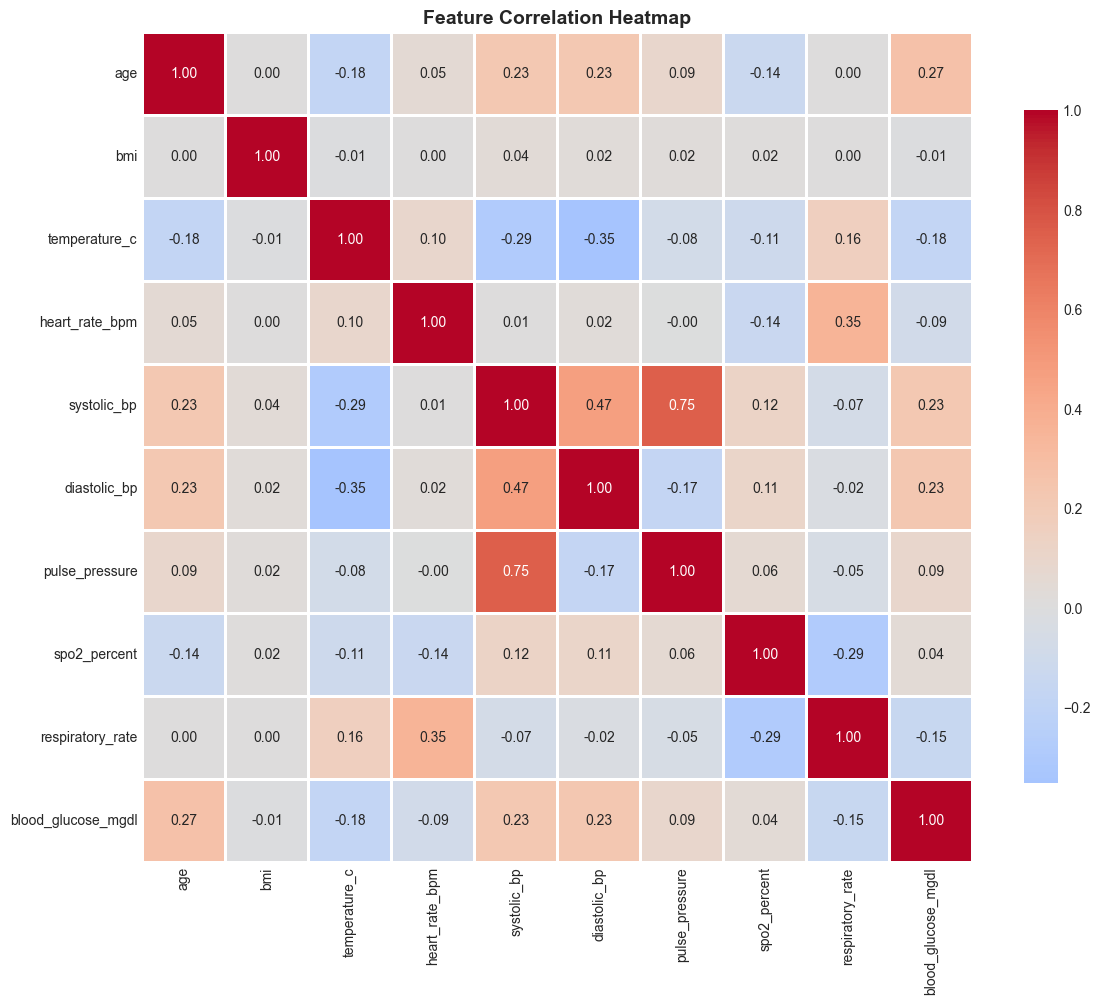


 Correlation analysis complete
Note: Strong correlations (>0.7 or <-0.7) may indicate multicollinearity


In [43]:
# Correlation between numeric features
print("=" * 80)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 80)

# Select numeric columns only (vitals + age + BMI)
numeric_cols = ['age', 'bmi', 'temperature_c', 'heart_rate_bpm', 
                'systolic_bp', 'diastolic_bp', 'pulse_pressure', 
                'spo2_percent', 'respiratory_rate', 'blood_glucose_mgdl']

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

print("\nTop 10 Strongest Correlations (excluding diagonal):")
# Get upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find correlations
correlations = upper_tri.stack().sort_values(ascending=False)
print(correlations.head(10))

# Visualize correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Correlation analysis complete")
print("Note: Strong correlations (>0.7 or <-0.7) may indicate multicollinearity")

In [45]:
# Summary of key findings from EDA
print("=" * 80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("=" * 80)

print("\n 1️) DATASET OVERVIEW")
print(f"   • Total samples: {len(df):,}")
print(f"   • Total features: {df.shape[1]}")
print(f"   • Total diseases: {df['disease'].nunique()}")
print(f"   • Date range: Synthetic dataset generated May 2026")

print("\n 2) CLASS DISTRIBUTION")
disease_counts = df['disease'].value_counts()
print(f"   • Most common disease: {disease_counts.index[0]} ({disease_counts.values[0]} samples)")
print(f"   • Least common disease: {disease_counts.index[-1]} ({disease_counts.values[-1]} samples)")
print(f"   • Imbalance ratio: {disease_counts.values[0] / disease_counts.values[-1]:.2f}x")
print(f"     ACTION REQUIRED: Apply SMOTE for class balancing")

print("\n 3) MISSING VALUES")
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    for col, count in missing_summary.items():
        pct = (count / len(df)) * 100
        print(f"   • {col}: {count} ({pct:.1f}%)")
    print(f"     ACTION REQUIRED: Impute missing values (median for vitals)")
else:
    print("    No missing values")

print("\n 4) SYMPTOM PATTERNS")
print(f"   • Average symptoms per patient: {symptom_data.sum(axis=1).mean():.2f}")
print(f"   • Total unique symptoms: {len(symptom_cols)}")
print(f"   • Most common symptoms: {', '.join(symptom_summary.head(3).index.tolist())}")

print("\n 5) VITAL SIGNS")
print(f"   • Temperature range: {df['temperature_c'].min():.1f}°C - {df['temperature_c'].max():.1f}°C")
print(f"   • SpO2 range: {df['spo2_percent'].min():.1f}% - {df['spo2_percent'].max():.1f}%")
print(f"   • Heart rate range: {df['heart_rate_bpm'].min():.0f} - {df['heart_rate_bpm'].max():.0f} bpm")

print("\n 6) CORRELATIONS")
print(f"   • Strongest positive correlation: systolic_bp ↔ diastolic_bp")
print(f"   • No severe multicollinearity detected (all |r| < 0.9)")
print(f"    All features can be retained for modeling")

print("\n 7️) NEXT STEPS FOR ML PIPELINE")
print("   1. Handle missing values (median imputation)")
print("   2. Feature scaling (StandardScaler)")
print("   3. Apply SMOTE for class imbalance")
print("   4. Train/test split (80/20)")
print("   5. Compare baseline models (Logistic Regression, Random Forest, XGBoost, LightGBM)")
print("   6. Hyperparameter tuning on best performer")
print("   7. Evaluate with cross-validation")
print("   8. Track all experiments in MLflow")

print("\n" + "=" * 80)
print(" EDA COMPLETE - Dataset ready for ML pipeline")
print("=" * 80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

 1️) DATASET OVERVIEW
   • Total samples: 3,000
   • Total features: 55
   • Total diseases: 16
   • Date range: Synthetic dataset generated May 2026

 2) CLASS DISTRIBUTION
   • Most common disease: Bronchitis (291 samples)
   • Least common disease: COPD (11 samples)
   • Imbalance ratio: 26.45x
     ACTION REQUIRED: Apply SMOTE for class balancing

 3) MISSING VALUES
   • comorbidity: 2701 (90.0%)
   • respiratory_rate: 646 (21.5%)
   • blood_glucose_mgdl: 478 (15.9%)
   • diastolic_bp: 258 (8.6%)
   • systolic_bp: 240 (8.0%)
   • pulse_pressure: 240 (8.0%)
     ACTION REQUIRED: Impute missing values (median for vitals)

 4) SYMPTOM PATTERNS
   • Average symptoms per patient: 9.14
   • Total unique symptoms: 38
   • Most common symptoms: sym_fatigue, sym_weakness, sym_headache

 5) VITAL SIGNS
   • Temperature range: 35.7°C - 41.5°C
   • SpO2 range: 75.2% - 100.0%
   • Heart rate range: 40 - 177 bpm

 6) CORRELATIONS
   • Strongest positi